# Use case — community detection on an embedding corpus (how many groups?)

You have a pile of item embeddings from some model — product vectors, document vectors, user
vectors — and you want the **natural groups**, but you *don't know how many there are*. k-means and
GMM force you to pick `k`; **`method="leiden"`** reads the number of communities off the similarity
graph of the microclusters and returns it. This notebook:

1. builds a realistic embedding corpus (themes of very different sizes, two of them overlapping);
2. lets **Leiden discover the theme count** with no `k`, and scores it against the latent themes;
3. uses **`resolution` (γ)** and the **CPM** objective to move between coarser and finer groupings;
4. flags the *ambiguous* items with **`consensus`** stability.

```bash
pip install betula-cluster matplotlib seaborn pandas scikit-learn
```

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import adjusted_rand_score
from sklearn.preprocessing import StandardScaler

import betula_cluster

sns.set_theme(style="whitegrid", context="notebook", palette="deep")

print("betula-cluster", betula_cluster.__version__)
plt.rcParams.update({"figure.dpi": 110, "axes.titleweight": "bold"})

betula-cluster 0.7.0


## A realistic embedding corpus

Six latent themes of **very unequal size** (a couple of big ones, some niches) in a 24-dim
embedding space. Themes 4 and 5 sit close together — a coarse view should merge them, a fine view
should keep them apart. This unequal-size, variable-separation structure is exactly where "just run
k-means with `k=6`" is brittle.

In [2]:
DIM = 24
rng = np.random.default_rng(7)
theme_sizes = [600, 420, 300, 180, 140, 90]
centers = rng.normal(0, 1, (6, DIM)) * 3.0
centers[5] = centers[4] + rng.normal(0, 0.4, DIM)  # theme 5 sits next to theme 4 (will merge/split)

X = np.vstack([rng.normal(centers[t], 0.9, (n, DIM)) for t, n in enumerate(theme_sizes)])
y = np.concatenate([np.full(n, t) for t, n in enumerate(theme_sizes)])
X = StandardScaler().fit_transform(X)
proj = PCA(n_components=2, random_state=0).fit_transform(X)
print(f"{len(X)} items, {DIM}-dim embeddings, {len(theme_sizes)} latent themes of sizes {theme_sizes}")

1730 items, 24-dim embeddings, 6 latent themes of sizes [600, 420, 300, 180, 140, 90]


## Leiden discovers the theme count — no `k`

`method="leiden"` ignores `n_clusters`. Pair it with a moderate `threshold` so the microcluster
graph resolves the themes. At this coarse γ it returns **five** communities at ARI ≈ 0.98 — the two
overlapping themes (4 and 5) merge into one, which is the honest read of a graph that connects them;
`resolution` sharpens or coarsens that next.

Leiden found 5 communities (no k given); ARI vs latent themes = 0.976


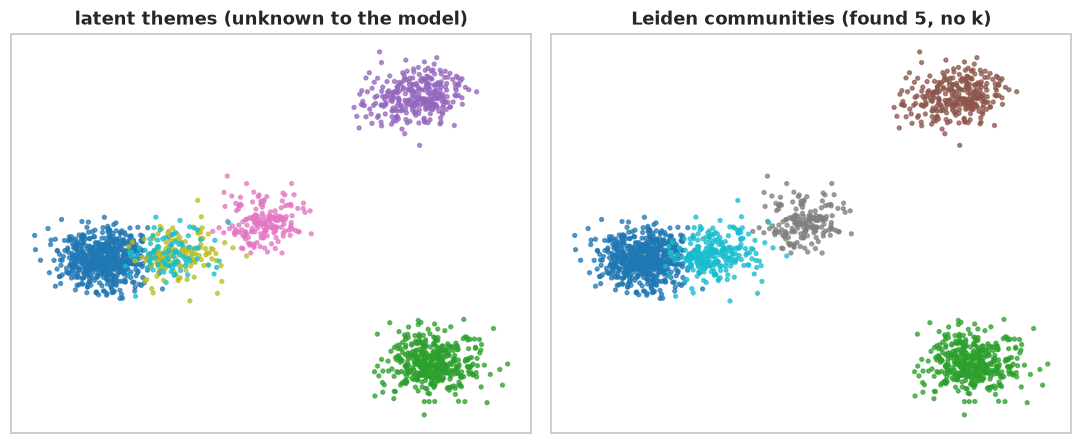

In [3]:
LEIDEN_KW = dict(method="leiden", threshold=0.4, max_leaves=800, seed=0)
labels = betula_cluster.fit_predict(X, resolution=1.0, **LEIDEN_KW)
n_found = len(set(labels))
print(f"Leiden found {n_found} communities (no k given); ARI vs latent themes = {adjusted_rand_score(y, labels):.3f}")

fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(10, 4.2))
ax0.scatter(*proj.T, c=y, cmap="tab10", s=6, alpha=0.7)
ax0.set(title="latent themes (unknown to the model)", xticks=[], yticks=[])
ax1.scatter(*proj.T, c=labels, cmap="tab10", s=6, alpha=0.7)
ax1.set(title=f"Leiden communities (found {n_found}, no k)", xticks=[], yticks=[])
fig.tight_layout()

## Granularity — the `resolution` knob and the CPM objective

`resolution` (γ) is the one knob: higher γ ⇒ more, smaller communities. Sweeping it traces the whole
merge/split hierarchy, so you can pick the granularity you want instead of guessing `k`. The
**CPM** objective (`method="leiden-cpm"`) is resolution-limit-free — its γ lives on a smaller,
density scale.

CPM objective (γ=0.008): 5 communities, ARI = 0.976


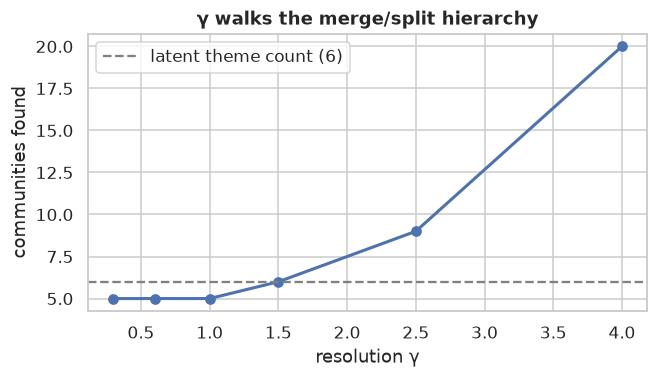

In [4]:
gammas = [0.3, 0.6, 1.0, 1.5, 2.5, 4.0]
counts = [len(set(betula_cluster.fit_predict(X, resolution=g, **LEIDEN_KW))) for g in gammas]

fig, ax = plt.subplots(figsize=(6, 3.6))
ax.plot(gammas, counts, "o-", lw=2)
ax.axhline(len(theme_sizes), ls="--", c="grey", label="latent theme count (6)")
ax.set(xlabel="resolution γ", ylabel="communities found", title="γ walks the merge/split hierarchy")
ax.legend()
fig.tight_layout()

cpm = betula_cluster.fit_predict(X, method="leiden-cpm", threshold=0.4, max_leaves=800, resolution=0.008, seed=0)
print(f"CPM objective (γ=0.008): {len(set(cpm))} communities, ARI = {adjusted_rand_score(y, cpm):.3f}")

## Which items are ambiguous? — `consensus`

The CF-tree depends on insertion order, and the overlapping themes have genuinely uncertain members.
`consensus` clusters several random permutations and votes, giving a per-item **stability** score:
the theme cores are confident, the overlap seam between themes 4 and 5 is not.

mean stability 0.96; 22% of items are unstable


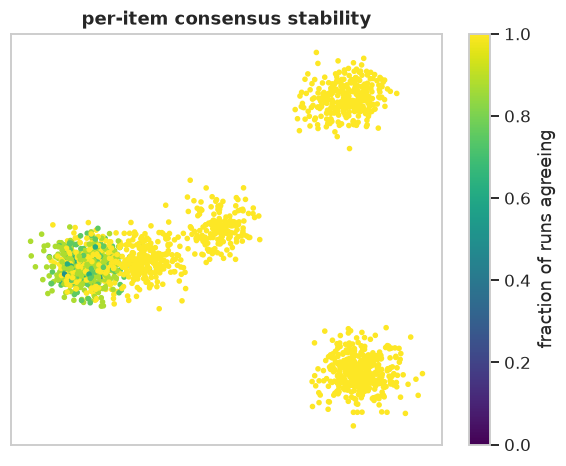

In [5]:
res = betula_cluster.consensus(X, n_clusters=6, n_runs=8, method="kmeans", threshold=0.2, n_jobs=-1)
print(f"mean stability {res.mean_confidence:.2f}; {(res.confidence < 1.0).mean():.0%} of items are unstable")

fig, ax = plt.subplots(figsize=(5.4, 4.4))
sc = ax.scatter(*proj.T, c=res.confidence, cmap="viridis", s=7, vmin=0, vmax=1)
ax.set(title="per-item consensus stability", xticks=[], yticks=[])
fig.colorbar(sc, ax=ax, label="fraction of runs agreeing")
fig.tight_layout()

## Why this beats "just pick k"

For reference, k-means *must* be told the count, and gets it wrong if you guess wrong:

In [6]:
rows = []
for k in (4, 6, 8):
    km = KMeans(n_clusters=k, n_init=10, random_state=0).fit_predict(X)
    rows.append({"method": f"k-means (k={k})", "communities": k, "ARI": round(adjusted_rand_score(y, km), 3)})
rows.append({"method": "Leiden (no k)", "communities": n_found, "ARI": round(adjusted_rand_score(y, labels), 3)})
print(pd.DataFrame(rows).to_string(index=False))

       method  communities   ARI
k-means (k=4)            4 0.753
k-means (k=6)            6 0.789
k-means (k=8)            8 0.606
Leiden (no k)            5 0.976


**Takeaway.** When you don't know how many groups your embeddings hold, `method="leiden"` finds a
count and a partition from the graph structure alone; `resolution` (or CPM) dials the granularity,
and `consensus` tells you which items to trust. All of it runs on the compressed CF microclusters,
so it scales with the number of leaves, not the corpus size. See the
[Usage guide](../../docs/USAGE.md) and [notebook 13](../13_graph_clustering.ipynb).